# KNN

In [ ]:
import heapq # heapq是Python里的堆结构，维护当前找到的 k 个最近邻
from dataclasses import dataclass # 快速定义一个只保存数据的类
from typing import Optional, Any, List, Tuple #
import numpy as np

## kdtree树类

In [ ]:
@dataclass # 极大地简化那些“主要用于存储数据的类”的编写，补充好创建 (__init__)、观察 (__repr__) 和比较 (__eq__)的内容
class KDNode:
    """
    kd 树的节点类。
    每个节点保存：
    1. 当前样本点 point
    2. 当前样本点对应的标签 label
    3. 当前节点使用哪个坐标轴 axis 进行切分
    4. 左子树 left
    5. 右子树 right
    """
    point: np.ndarray
    label: Any
    axis: int
    left: Optional["KDNode"] = None # Optional:这个变量要么是指定的类型，要么是 None（空值）
    # 加上双引号，这叫做“前向引用 (Forward Reference)”
    right: Optional["KDNode"] = None

class KDTree:
    """
    kd 树类。

    作用：
    1. 根据训练数据 X 和标签 y 构造 kd 树；
    2. 对给定测试点，搜索最近的 k 个邻居。
    """
    def __init__(self, p: float = 2, split_strategy: str = 'cycle'):
        """
        p : float
            Lp 距离中的 p。
        split_strategy : str
            kd 树切分维度的选择方式。
            "cycle" 表示按维度循环切分；
            "variance" 表示每次选择方差最大的维度切分。
        """
        if p < 1 and p != np.inf:
            raise ValueError("p 必须满足 p >= 1,或者 p = np.inf")
        if split_strategy not in ("cycle", "variance"):
            raise ValueError("split_strategy 只能是 'cycle' 或 'variance'")
        self.p = p
        self.split_strategy = split_strategy
        self.root: KDNode | None = None  # 一个是“说明”，另一个是“动作”，未来在这个变量里，我打算存放一个KDNode对象，但也允许它暂时是空的。
        self.n_samples_: Optional[int] = None #
        self.n_feature_: Optional[int] = None

    def fit(self, X: np.ndarray, y: Optional[np.ndarray] = None):
        """
        构造 kd 树。
        X : np.ndarray, shape = (n_samples, n_features)
            训练样本特征矩阵。
        y : np.ndarray, shape = (n_samples,), optional
            每个样本对应的标签。
            如果 y=None，则默认标签为样本编号。
        """
        X = np.asarray(X, dtype = float)
        if X.ndim != 2:
            raise ValueError("X 必须是二维数组")
        n_samples, n_features = X.shape
        if y is None:
            y = np.arange(n_samples)
        else:
            y = np.asarray(y)

        self.n_samples = n_samples
        self.n_features = n_features

        self.root = self._build_tree(X, y, depth = 0) # 调用 _build_tree 递归构造 kd 树。

        return self

    def _build_tree(self, X: np.ndarray, y: np.ndarray, depth: int) -> Optional[KDNode]:
        """
        递归构造 kd 树。
        核心思想：
        1. 选择一个切分维度 axis；
        2. 按照 axis 这一维对样本排序；
        3. 取中位数样本作为当前节点；
        4. 中位数左边的数据构造左子树；
        5. 中位数右边的数据构造右子树。
        """
        n_samples = X.shape[0]
        if n_samples == 0: #
            return None

        if self.split_strategy == 'cycle':
            axis = depth % self.n_features
        else:
            axis = int(np.argmax(np.var(X, axis = 0)))

        sorted_indices = np.argsort(X[:, axis], kind = 'mergesort') #稳定排序的意思是：如果两个点在当前维度上的值相同，它们原来的相对顺序尽量保持不变。
        X_sorted = X[sorted_indices]
        y_sorted = y[sorted_indices]
        median = n_samples // 2

        node = KDNode(
            point = X_sorted[median],
            label = y_sorted[median],
            axis = axis, # 当前节点记录这次使用哪个维度进行切分。
            left = self._build_tree(
                X_sorted[:median],
                y_sorted[:median],
                depth + 1
            ),
            right = self._build_tree(
                X_sorted[median + 1:],
                y_sorted[median + 1:],
                depth + 1
            )
        )
        return node

    def _distance(self, x1: np.ndarray, x2: np.ndarray) -> float:
        return float(np.linalg.norm(x1 - x2, ord = self.p))

    def query(self, point: np.ndarray, k: int = 1) -> List[Tuple[float, np.ndarray, Any]]:
        """
        查询距离 point 最近的 k 个样本点。
        参数
        ----------
        point : np.ndarray, shape = (n_features,)
            待查询样本点。
        k : int
            要搜索的最近邻个数。
        返回
        ----------
        neighbors : list
            返回一个列表，每个元素为：
            (distance, neighbor_point, neighbor_label)
            其中：
            distance 是距离；
            neighbor_point 是邻居点坐标；
            neighbor_label 是邻居点标签。
        """
        if self.root is None:
            raise RuntimeError("kd 树还没有构造，请先调用 fit(X, y)")

        point = np.asarray(point, dtype = float)
        if point.ndim != 1:
            raise ValueError("point 必须是一维数组，形状为 (n_features,)")
        if point.shape[0] != self.n_features:
            raise ValueError("point 的维度和训练数据维度不一致")
        if k <= 0:
            raise ValueError("k 必须是正整数")

        k = min(k, self.n_samples) # 如果用户要求的 k 比训练样本数还大，就自动改成训练样本数
        # heap 中每个元素是：(-distance, counter, point, label)
        heap = [] # 创建一个空堆，用来保存当前找到的最近邻。
        counter = 0 # 堆里面可能出现两个点距离相同，为了避免 Python 比较 numpy 数组时报错，我们加入一个计数器作为辅助排序项。

        def push_neighbor(distance:float, node: KDNode):
            """
            尝试把当前节点加入最近邻堆中。
            如果堆中元素不足 k 个，直接加入；
            如果堆中已有 k 个元素，则只有当前点比最远邻居更近时才替换。
            """
            nonlocal counter # 说明这个函数要修改外层函数里的 counter。
            item = (-distance, counter, node.point, node.label) # 用负距离实现最大堆效果
            counter += 1 # 保证每个 item 的第二项不同

            if len(heap) < k: # 如果堆里还没存满k个邻居，就直接加入。
                heapq.heappush(heap, item) # heappush将新元素 item 插入到堆中，并自动调整位置以保持小顶堆的特性。
            else:
                current_worst_distance = -heap[0][0] # 如果已经有k个邻居了，就先取出当前最远邻居的距离，因为堆顶存的是负距离，所以要加负号变回来
                if distance < current_worst_distance: # 如果当前节点比当前最远邻居更近，就替换掉最远的那个
                    heapq.heapreplace(heap, item) # heapreplace(heap, item): 先弹出堆中最小的元素，然后再把 item 推入堆中。

        def search(node: Optional[KDNode]):
            """
            递归搜索 kd 树。

            搜索过程：
            1. 根据目标点和当前节点在切分维度上的大小，先搜索更可能包含近邻的一侧；
            2. 更新当前节点是否属于最近邻；
            3. 判断另一侧子树是否可能存在更近的点；
            4. 如果可能，则回溯搜索另一侧。
            """
            if node is None: # 如果当前节点为空，就返回。递归终止条件
                return # return导致回溯
            axis = node.axis # 取当前节点的切分维度

            if point[axis] < node.point[axis]: # 比较查询点和当前节点在切分维度上的坐标。如果查询点更小，说明查询点落在左侧区域。
                near_branch = node.left
                far_branch = node.right
            else:
                near_branch = node.right
                far_branch = node.left

            search(near_branch) # 先搜索更可能包含最近邻的一侧。
            # 先走目标点所在的那一边，当代码走到叶子节点并开始回溯（从最底层的函数调用往上返回）时，才会真正开始计算距离。
            # 因为在递归的时候前面的执行被暂停了，当进入空节点时会回溯
            distance = self._distance(point, node.point) # 计算查询点到当前节点的距离。
            push_neighbor(distance, node) # 尝试把当前节点加入最近邻集合。如果它足够近，就加入或替换。

            if len(heap) < k:
                worst_distance = np.inf # 如果目前还没有找到 k 个邻居，那么必须继续搜索其他区域。
            else:
                worst_distance = -heap[0][0] # 如果已经有 k 个邻居，那么堆顶就是当前最远邻居。

            plane_distance = abs(point[axis] - node.point[axis]) # 计算查询点到当前切分超平面的距离。
            if plane_distance <= worst_distance:
                search(far_branch) # 查询点到切分平面的距离，小于当前最远近邻距离，那么另一边仍然可能存在更近的点，所以必须搜索另一边。

        search(self.root) # 从根节点开始递归搜索。

        neighbors = [
            (-neg_distance, neighbor_point, neighbor_label)
            for neg_distance, _, neighbor_point, neighbor_label in heap
        ] # 把堆里面保存的邻居转换成正常格式
        neighbors.sort(key = lambda item: item[0]) # 按照距离从小到大排序。
        return neighbors

class KNNClassifier:
    """
    基于 kd 树实现的 KNN 分类器。
    支持：
    1. 设定 k 值；
    2. 设定 Lp 距离；
    3. 多数投票分类；
    4. 距离加权投票分类；
    5. predict；
    6. predict_proba。
    """
    def __init__(self, n_neighbors: int = 5, p: float = 2, weights: str = "uniform", split_strategy: str = "cycle"):
        """
        weights : str
            投票权重方式。
            "uniform" 表示普通多数投票；
            "distance" 表示距离越近，权重越大。
        """
        if n_neighbors <= 0:
            raise ValueError("n_neighbors 必须是正整数")

        if weights not in ("uniform", "distance"):
            raise ValueError("weights 只能是 'uniform' 或 'distance'")

        self.n_neighbors = n_neighbors
        self.p = p
        self.weights = weights
        self.split_strategy = split_strategy
        self.tree_: Optional[KDTree] = None
        self.classes_: Optional[np.ndarray] = None # 保存类别集合
        self.class_to_index: Optional[dict] = None # 保存类别到下标的映射
        self.n_features: Optional[int] = None
        self.n_samples: Optional[int] = None

    def fit(self, X: np.ndarray, y: np.ndarray):
        """
        训练 KNN 分类器。
        注意：
        KNN 本身没有真正的参数训练过程。
        这里的 fit 主要做两件事：
        1. 保存类别信息；
        2. 构造 kd 树，用于加速最近邻搜索。
        """
        X = np.asarray(X, dtype = float)
        y = np.asarray(y)
        if X.ndim != 2:
            raise ValueError("X 必须是二维数组，形状为 (n_samples, n_features)")
        if y.ndim != 1:
            y = y.ravel()
        if X.shape[0] != y.shape[0]:
            raise ValueError("X 和 y 的样本数量不一致")
        self.n_samples, self.n_features= X.shape
        self.classes_ = np.unique(y)
        self.class_to_index_ = {
            label: index for index, label in enumerate(self.classes_)
        }
        self.tree_ = KDTree(p = self.p, split_strategy= self.split_strategy)
        self.tree_.fit(X, y)
        return self

    def _check_X_query(self, X: np.ndarray) -> np.ndarray:
        """
        检查预测输入 X 的形状。
        如果输入是单个样本，例如：
        [1.0, 2.0]
        会自动转成：
        [[1.0, 2.0]]
        """
        X = np.asarray(X, dtype=float)

        if X.ndim == 1:
            X = X.reshape(1, -1)

        if X.ndim != 2:
            raise ValueError("X 必须是一维或二维数组")

        if X.shape[1] != self.n_features:
            raise ValueError("X 的特征维度和训练数据不一致")

        return X

    def _vote(self, neighbors: List[Tuple[float, np.ndarray, Any]]) -> np.ndarray:
        """
        根据最近邻进行投票。
        返回每个类别的投票权重。
        """
        votes = np.zeros(len(self.classes_), dtype = float)
        if self.weights == "uniform":
            for distance, point, label in neighbors:
                class_index = self.class_to_index_[label]
                votes[class_index] += 1.0
        else:
            zero_distance_neighbors = [
                item for item in neighbors if item[0] == 0.0 # 找出距离为 0 的邻居。
            ]

            if len(zero_distance_neighbors) > 0:
                # 如果测试点和某些训练点完全重合，
                # 则只使用这些距离为 0 的点进行投票。
                for distance, point, label in zero_distance_neighbors:
                    class_index = self.class_to_index_[label]
                    votes[class_index] += 1.0
            else:
                for distance, point, label in neighbors:
                    class_index = self.class_to_index_[label]
                    votes[class_index] += 1.0 / distance

        return votes

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        预测样本类别。

        参数
        ----------
        X : np.ndarray
            可以是单个样本，形状为 (n_features,)；
            也可以是多个样本，形状为 (n_samples, n_features)。

        返回
        ----------
        y_pred : np.ndarray
            预测类别。
        """
        if self.tree_ is None:
            raise RuntimeError("模型还没有训练，请先调用 fit(X, y)")

        X = self._check_X_query(X)

        y_pred = []

        for point in X:
            neighbors = self.tree_.query( # 用 kd 树查询当前测试点的 k 个最近邻
                point,
                k=self.n_neighbors
            )

            votes = self._vote(neighbors) # 根据这些邻居的标签投票。

            predicted_class_index = int(np.argmax(votes)) # 找到票数最多的类别下标。
            predicted_class = self.classes_[predicted_class_index] # 根据下标找到真正类别。

            y_pred.append(predicted_class)

        return np.asarray(y_pred)

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """
        预测每个样本属于各类别的概率。

        概率的计算方式：
        某类的投票权重 / 所有类别的投票权重之和。
        """
        if self.tree_ is None:
            raise RuntimeError("模型还没有训练，请先调用 fit(X, y)")

        X = self._check_X_query(X)

        probabilities = []

        for point in X:
            neighbors = self.tree_.query(
                point,
                k=self.n_neighbors
            )

            votes = self._vote(neighbors)
            total = np.sum(votes)

            if total == 0:
                proba = np.ones(len(self.classes_)) / len(self.classes_) # 如果总票数为 0，就给每个类别相同概率。
            else:
                proba = votes / total

            probabilities.append(proba)

        return np.asarray(probabilities)

    def kneighbors(self, X: np.ndarray):
        """
        返回每个测试点的 k 个最近邻。

        返回格式：
        [
            [
                (distance, neighbor_point, neighbor_label),
                ...
            ],
            ...
        ]
        """
        if self.tree_ is None:
            raise RuntimeError("模型还没有训练，请先调用 fit(X, y)")

        X = self._check_X_query(X)

        all_neighbors = []

        for point in X:
            neighbors = self.tree_.query(
                point,
                k=self.n_neighbors
            )
            all_neighbors.append(neighbors)

        return all_neighbors

    def score(self, X: np.ndarray, y: np.ndarray) -> float:
        """
        计算分类准确率。
        """
        y = np.asarray(y)
        y_pred = self.predict(X)

        return float(np.mean(y_pred == y))


类别顺序：
['A' 'B' 'C']

测试集准确率：
1.0

自定义查询点预测结果：

查询点 1: [0. 0.]
预测类别: A
预测概率:
  P(y = A) = 1.0000
  P(y = B) = 0.0000
  P(y = C) = 0.0000

查询点 2: [4. 0.]
预测类别: B
预测概率:
  P(y = A) = 0.0000
  P(y = B) = 1.0000
  P(y = C) = 0.0000

查询点 3: [2.  3.5]
预测类别: C
预测概率:
  P(y = A) = 0.0000
  P(y = B) = 0.0000
  P(y = C) = 1.0000

查询点 4: [2.  1.2]
预测类别: C
预测概率:
  P(y = A) = 0.0000
  P(y = B) = 0.2857
  P(y = C) = 0.7143

查询点 5: [2.2 0.4]
预测类别: B
预测概率:
  P(y = A) = 0.1429
  P(y = B) = 0.8571
  P(y = C) = 0.0000

被重点展示的查询点：
[2.  1.2]
预测类别： C
最近邻：
距离 = 0.9746, 邻居点 = [2.9738806  1.23819595], 标签 = B
距离 = 1.0549, 邻居点 = [2.36010755 2.19156051], 标签 = C
距离 = 1.0767, 邻居点 = [2.40096529 0.2007836 ], 标签 = B
距离 = 1.1656, 邻居点 = [3.10361898 1.57500617], 标签 = C
距离 = 1.2728, 邻居点 = [1.89963278 2.46882814], 标签 = C
距离 = 1.4749, 邻居点 = [2.68692691 2.50520546], 标签 = C
距离 = 1.4926, 邻居点 = [2.13243002 2.68670895], 标签 = C


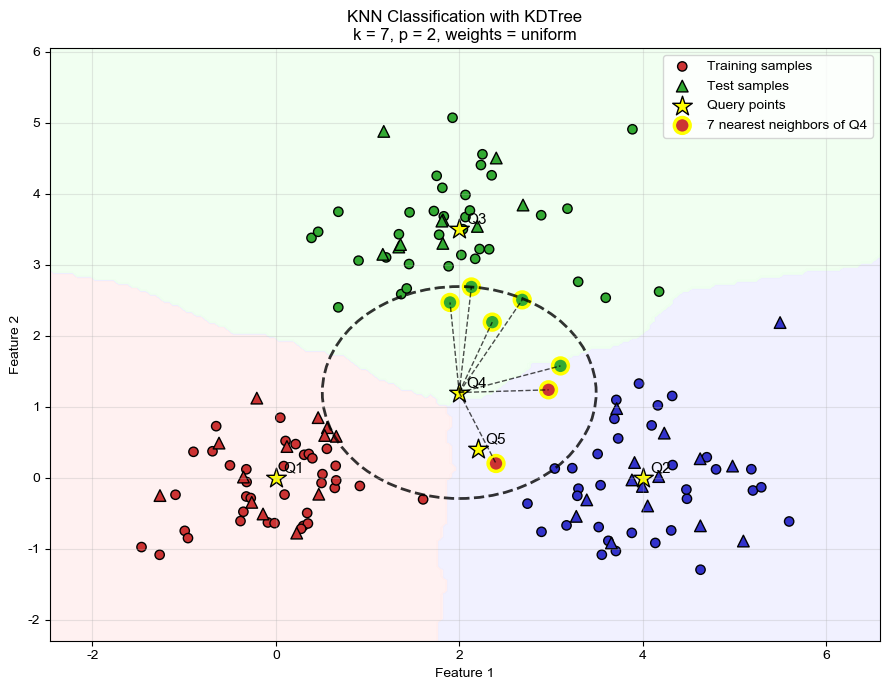

In [13]:
if __name__ == "__main__":
    import matplotlib.pyplot as plt
    from matplotlib.colors import ListedColormap
    from matplotlib.patches import Circle

    # 这个例子构造 3 类二维数据：
    # A 类：左下方
    # B 类：右下方
    # C 类：上方

    rng = np.random.default_rng(42)

    # -------------------------
    # 1. 构造三类二维数据
    # -------------------------
    n_per_class = 50

    center_A = np.array([0.0, 0.0])
    center_B = np.array([4.0, 0.0])
    center_C = np.array([2.0, 3.5])

    # scale 越大，类别之间重叠越明显，分类越困难
    X_A = center_A + rng.normal(0, 0.75, size=(n_per_class, 2))
    X_B = center_B + rng.normal(0, 0.75, size=(n_per_class, 2))
    X_C = center_C + rng.normal(0, 0.75, size=(n_per_class, 2))

    y_A = np.array(["A"] * n_per_class)
    y_B = np.array(["B"] * n_per_class)
    y_C = np.array(["C"] * n_per_class)

    X = np.vstack([X_A, X_B, X_C])
    y = np.concatenate([y_A, y_B, y_C])

    # -------------------------
    # 2. 打乱数据
    # -------------------------
    indices = rng.permutation(len(X)) # 产生一个随机顺序
    X = X[indices]
    y = y[indices]

    # -------------------------
    # 3. 划分训练集和测试集
    # -------------------------
    train_ratio = 0.75
    n_train = int(len(X) * train_ratio)

    X_train = X[:n_train]
    y_train = y[:n_train]

    X_test = X[n_train:]
    y_test = y[n_train:]

    # -------------------------
    # 4. 创建 KNN 模型
    # -------------------------
    model = KNNClassifier(
        n_neighbors=7,
        p=2,
        weights="uniform",
        split_strategy="cycle"
    )

    model.fit(X_train, y_train)

    print("类别顺序：")
    print(model.classes_)

    print("\n测试集准确率：")
    print(model.score(X_test, y_test))

    # -------------------------
    # 5. 构造网格，用来画决策边界
    # -------------------------
    x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
    y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0

    h = 0.05

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    grid_points = np.c_[xx.ravel(), yy.ravel()]

    # 对网格上的每个点都预测类别
    grid_pred = model.predict(grid_points)

    # 把类别 A/B/C 转成 0/1/2，方便画图
    class_to_number = {
        label: index for index, label in enumerate(model.classes_)
    }

    Z = np.array([
        class_to_number[label] for label in grid_pred
    ])

    Z = Z.reshape(xx.shape)

    # -------------------------
    # 6. 选择几个查询点
    # -------------------------
    X_query = np.array([
        [0.0, 0.0],    # 靠近 A
        [4.0, 0.0],    # 靠近 B
        [2.0, 3.5],    # 靠近 C
        [2.0, 1.2],    # 三类之间的模糊区域
        [2.2, 0.4],    # A 和 B 之间
    ])

    query_pred = model.predict(X_query)
    query_proba = model.predict_proba(X_query)

    print("\n自定义查询点预测结果：")
    for i in range(len(X_query)):
        print(f"\n查询点 {i + 1}: {X_query[i]}")
        print("预测类别:", query_pred[i])
        print("预测概率:")

        for cls, proba in zip(model.classes_, query_proba[i]):
            print(f"  P(y = {cls}) = {proba:.4f}")

    # -------------------------
    # 7. 选择一个点，显示它的 k 个最近邻
    # -------------------------
    selected_index = 3
    selected_point = X_query[selected_index]

    selected_neighbors = model.kneighbors(selected_point)[0]

    print("\n被重点展示的查询点：")
    print(selected_point)
    print("预测类别：", query_pred[selected_index])
    print("最近邻：")

    for distance, point, label in selected_neighbors:
        print(f"距离 = {distance:.4f}, 邻居点 = {point}, 标签 = {label}")

    # -------------------------
    # 8. 可视化
    # -------------------------
    plt.rcParams["font.sans-serif"] = [
        "Arial Unicode MS",
        "SimHei",
        "Microsoft YaHei"
    ]
    plt.rcParams["axes.unicode_minus"] = False

    cmap_light = ListedColormap(["#FFEEEE", "#EEEEFF", "#EEFFEE"])
    cmap_bold = ListedColormap(["#CC3333", "#3333CC", "#33AA33"])

    fig, ax = plt.subplots(figsize=(9, 7))

    # 画决策区域
    ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)

    # 训练集类别转数字
    y_train_num = np.array([
        class_to_number[label] for label in y_train
    ])

    y_test_num = np.array([
        class_to_number[label] for label in y_test
    ])

    # 画训练集
    ax.scatter(
        X_train[:, 0],
        X_train[:, 1],
        c=y_train_num,
        cmap=cmap_bold,
        edgecolor="k",
        s=45,
        label="Training samples"
    )

    # 画测试集
    ax.scatter(
        X_test[:, 0],
        X_test[:, 1],
        c=y_test_num,
        cmap=cmap_bold,
        edgecolor="k",
        marker="^",
        s=70,
        label="Test samples"
    )

    # 画自定义查询点
    ax.scatter(
        X_query[:, 0],
        X_query[:, 1],
        c="yellow",
        edgecolor="black",
        marker="*",
        s=220,
        label="Query points"
    )

    # 给查询点标号
    for i, point in enumerate(X_query):
        ax.text(
            point[0] + 0.08,
            point[1] + 0.08,
            f"Q{i + 1}",
            fontsize=11,
            weight="bold"
        )

    # 重点展示 selected_point 的 k 个最近邻
    neighbor_points = np.array([
        item[1] for item in selected_neighbors
    ])

    neighbor_labels = np.array([
        item[2] for item in selected_neighbors
    ])

    neighbor_labels_num = np.array([
        class_to_number[label] for label in neighbor_labels
    ])

    ax.scatter(
        neighbor_points[:, 0],
        neighbor_points[:, 1],
        c=neighbor_labels_num,
        cmap=cmap_bold,
        edgecolor="yellow",
        linewidth=2.5,
        s=130,
        label=f"{model.n_neighbors} nearest neighbors of Q{selected_index + 1}"
    )

    # 画查询点到最近邻的连线
    for distance, point, label in selected_neighbors:
        ax.plot(
            [selected_point[0], point[0]],
            [selected_point[1], point[1]],
            "k--",
            linewidth=1,
            alpha=0.7
        )

    # 画最近邻半径圆
    radius = selected_neighbors[-1][0]

    circle = Circle(
        selected_point,
        radius,
        fill=False,
        linestyle="--",
        linewidth=2,
        edgecolor="black",
        alpha=0.8
    )

    ax.add_patch(circle)

    ax.set_title(
        f"KNN Classification with KDTree\n"
        f"k = {model.n_neighbors}, p = {model.p}, weights = {model.weights}"
    )

    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## sklearn - KNN

#### 简单回归KNeighborsClassifier

In [12]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

X_train = np.array([
    [1, 2],
    [2, 3],
    [3, 3],
    [6, 5],
    [7, 7],
    [8, 6]
])

y_train = np.array([0, 0, 0, 1, 1, 1])

X_test = np.array([
    [2, 2],
    [7, 6]
])

model = KNeighborsClassifier(n_neighbors = 3)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(y_pred)

[0 1]


#### KNN的基本流程

也有
NearestNeighbors是无监督最近邻搜索工具，主要用于返回邻居索引和距离，不直接输出类别。官方文档也把它定义为实现邻居搜索的无监督学习器。

In [22]:
from sklearn.datasets import load_iris # 加载著名的鸢尾花（Iris）数据集
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

iris = load_iris()
X = iris.data # 从打包好的对象中提取出用于训练模型的特征数据（即输入变量）
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size = 0.2,
    random_state = 42,
    stratify = y) #   stratify=y代表根据y进行分层抽样
model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors = 5))
    ])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("准确率:", accuracy_score(y_test, y_pred))
print("混淆矩阵:")
print(confusion_matrix(y_test, y_pred))
print("分类报告:")
print(classification_report(y_test, y_pred))

x_query = X_test[:1]
x_query_scaled = model.named_steps["scaler"].transform(x_query) # 先进行标准化，因为训练时也是经过了标准化的
distances, indices = model.named_steps["knn"].kneighbors(x_query_scaled)
print("最近邻距离:")
print(distances)

print("最近邻在训练集中的索引:")
print(indices)

print("最近邻标签:")
print(y_train[indices[0]])

准确率: 0.9333333333333333
混淆矩阵:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]
分类报告:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.83      1.00      0.91        10
           2       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30

最近邻距离:
[[0.21093439 0.23097652 0.34650029 0.49871876 0.49871876]]
最近邻在训练集中的索引:
[[ 93   0 119  49  50]]
最近邻标签:
[0 0 0 0 0]


## KNN回归

In [19]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

X, y = make_regression(n_samples = 300,
                       n_features = 5,
                       noise = 10,
                       random_state = 42) # 生成回归分析模拟数据集的工具函数
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 42)
model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors= 5, weights = "distance"))
])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MSE: 1062.1165496086437
R2: 0.8766117964849803


### GridSearchCV选择最优参数

In [20]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

param_grid = {
    "knn__n_neighbors": [1, 3, 5, 7, 9, 11, 15],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2],
    "knn__algorithm": ["auto", "kd_tree", "ball_tree", "brute"]
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("最优参数:")
print(grid.best_params_)

print("交叉验证最优分数:")
print(grid.best_score_)

print("测试集分数:")
print(grid.score(X_test, y_test))

最优参数:
{'knn__algorithm': 'auto', 'knn__n_neighbors': 5, 'knn__p': 2, 'knn__weights': 'uniform'}
交叉验证最优分数:
0.9666666666666668
测试集分数:
0.9333333333333333


测试集准确率: 1.0


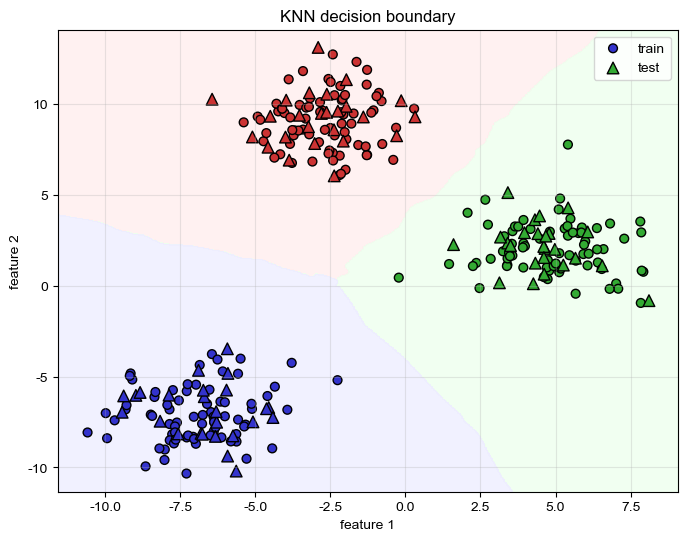

In [23]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap
from sklearn.datasets import make_blobs
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# 1. 构造二维三分类数据
X, y = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1.5,
    random_state=42
)

# 2. 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# 3. 模型
model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(
        n_neighbors=7,
        weights="uniform",
        p=2
    ))
])

model.fit(X_train, y_train)

print("测试集准确率:", model.score(X_test, y_test))

# 4. 构造网格
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

h = 0.05

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

grid = np.c_[xx.ravel(), yy.ravel()]

# 5. 对网格点预测
Z = model.predict(grid)
Z = Z.reshape(xx.shape)

# 6. 可视化
cmap_light = ListedColormap(["#FFEEEE", "#EEFFEE", "#EEEEFF"])
cmap_bold = ListedColormap(["#CC3333", "#33AA33", "#3333CC"])

plt.figure(figsize=(8, 6))

plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)

plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_train,
    cmap=cmap_bold,
    edgecolor="k",
    s=40,
    label="train"
)

plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_test,
    cmap=cmap_bold,
    edgecolor="k",
    marker="^",
    s=70,
    label="test"
)

plt.title("KNN decision boundary")
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()